In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv('../data/raw/application_train.csv')
print(f"Data Loaded: {df.shape}")

Data Loaded: (307511, 122)


In [2]:
# Ratio Feature 
# Business rationale documented for each feature

# 1. Debt to Income ratio
# How much total debt is the borrower taking on relative to annual income ?
# Higher Ratio = Less repayment buffer = higher default risk

df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# 2. Annuity to income
# What % of income goes towards loan repayment?
# Industry rule of thumb. Above 40% is high risk
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'] 

# 3. Credit to Goods ratio
# How much of the purchase is being financed vs paid upfront?
# Ratio of 1.0 means 100% financed - no borrower equity
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

# 4. Annuity to Credit Ration
# Implied loan tenure signal - lower ratio means longer repayment period
# Longer Tenure = more exposure to life event that cause defaulter 
df['ANNUITY_TO_CREDIT'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

# 5. Income per family member 
# Disposable income adjusted for dependents
df['INCOME_PER_PERSON'] = (df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0 , np.nan))

# 6. External Source Mean Score
# Average of three external credit score - reduce the noice of missingness
# More stable single signal than any individual score 
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1' , 'EXT_SOURCE_2' , 'EXT_SOURCE_3']].mean(axis=1)

# 7. External Source Weighted Mean
# Ext - 3 showed highest correlation - give it more weight 
df['EXT_SOURCE_WEIGHTED'] = (
    0.5 * df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].median()) + 
    0.3 * df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].median()) +
    0.2 * df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].median())
)

# Replace any infinity values with NaN across all new ratio features
ratio_cols = ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS',
              'ANNUITY_TO_CREDIT', 'INCOME_PER_PERSON',
              'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED']



print("Ratio features created successfully.")
print("\n New column added : 7")
print(f"\n Total column : {df.shape[1]}")

# Check for infinity first
for col in ratio_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        print(f"{col}: {inf_count} infinity values found — replacing with NaN")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

print("\nInfinity check complete")
df['DEBT_TO_INCOME'].head()

Ratio features created successfully.

 New column added : 7

 Total column : 129

Infinity check complete


0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: DEBT_TO_INCOME, dtype: float64

In [3]:
# Validate ratio features — do they outperform raw columns?
raw_cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 
            'AMT_ANNUITY', 'AMT_GOODS_PRICE',
            'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

new_cols = ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME',
            'CREDIT_TO_GOODS', 'ANNUITY_TO_CREDIT',
            'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN',
            'EXT_SOURCE_WEIGHTED']

compare_cols = raw_cols + new_cols

correlations = df[compare_cols].corrwith(df['TARGET']).abs()
correlations = correlations.sort_values(ascending=False)

print("=== RAW vs ENGINEERED FEATURE CORRELATION ===\n")
for col in correlations.index:
    tag = " ← ENGINEERED" if col in new_cols else ""
    print(f"{col:<35} {correlations[col]:.4f}{tag}")

=== RAW vs ENGINEERED FEATURE CORRELATION ===

EXT_SOURCE_MEAN                     0.2221 ← ENGINEERED
EXT_SOURCE_WEIGHTED                 0.2192 ← ENGINEERED
EXT_SOURCE_3                        0.1789
EXT_SOURCE_2                        0.1605
EXT_SOURCE_1                        0.1553
CREDIT_TO_GOODS                     0.0694 ← ENGINEERED
AMT_GOODS_PRICE                     0.0396
AMT_CREDIT                          0.0304
ANNUITY_TO_INCOME                   0.0143 ← ENGINEERED
AMT_ANNUITY                         0.0128
ANNUITY_TO_CREDIT                   0.0127 ← ENGINEERED
DEBT_TO_INCOME                      0.0077 ← ENGINEERED
INCOME_PER_PERSON                   0.0066 ← ENGINEERED
AMT_INCOME_TOTAL                    0.0040


In [4]:
# Check default rate by DTI bands — reveals non-linear relationship
df['DTI_BAND'] = pd.cut(df['DEBT_TO_INCOME'],
                         bins=[0, 1, 2, 3, 4, 5, 100],
                         labels=['0-1x','1-2x','2-3x',
                                 '3-4x','4-5x','5x+'])

print("=== DEFAULT RATE BY DEBT-TO-INCOME BAND ===")
dti_default = df.groupby('DTI_BAND')['TARGET'].agg(['mean','count'])
dti_default.columns = ['Default Rate %', 'Count']
dti_default['Default Rate %'] = (dti_default['Default Rate %'] * 100).round(2)
print(dti_default.to_string())

=== DEFAULT RATE BY DEBT-TO-INCOME BAND ===
          Default Rate %  Count
DTI_BAND                       
0-1x                6.44  16174
1-2x                7.70  60164
2-3x                8.69  64858
3-4x                9.11  48703
4-5x                8.47  36805
5x+                 7.38  80807


In [5]:
# Confirm current state before Step 3.2
print(f"Total columns: {df.shape[1]}")
print(f"Expected: 129 (122 original + 7 ratio features)")
print(f"\nRatio features present:")

ratio_cols = ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS',
              'ANNUITY_TO_CREDIT', 'INCOME_PER_PERSON',
              'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED']

for col in ratio_cols:
    present = col in df.columns
    print(f"  {col:<30} {'✓' if present else '✗ MISSING'}")

Total columns: 130
Expected: 129 (122 original + 7 ratio features)

Ratio features present:
  DEBT_TO_INCOME                 ✓
  ANNUITY_TO_INCOME              ✓
  CREDIT_TO_GOODS                ✓
  ANNUITY_TO_CREDIT              ✓
  INCOME_PER_PERSON              ✓
  EXT_SOURCE_MEAN                ✓
  EXT_SOURCE_WEIGHTED            ✓


In [6]:
# ── IS_MISSING FLAG FEATURES ─────────────────────────────────────────────────
# For every column with medium or high missingness, create a companion binary
# flag that captures the signal contained in the absence of data.
# 0 = value was present in original data
# 1 = value was missing in original data

# Reload the missingness strategy we saved in Step 2.3

import pandas as pd

missing_strategy = pd.read_csv('../docs/missingness_strategy.csv', index_col=0)

# Get medium and high missingness columns

medium_cols = missing_strategy[missing_strategy["Severity"] == 'Medium(10-50%)'].index.tolist()

high_cols = missing_strategy[missing_strategy["Severity"] == 'High(>50%)'].index.tolist()

flag_target_cols = medium_cols + high_cols

print(f"Medium missingness columns: {len(medium_cols)}")
print(f"High missingness columns:   {len(high_cols)}")
print(f"Total IS_MISSING flags to create: {len(flag_target_cols)}")




Medium missingness columns: 16
High missingness columns:   41
Total IS_MISSING flags to create: 57


In [7]:
# Create IS_MISSING flag for every medium and high missingness column
flags_created = []

for col in flag_target_cols:
    flag_name = f"{col}_IS_MISSING"
    df[flag_name] = df[col].isnull().astype(int)
    flags_created.append(flag_name)

print(f"IS_MISSING flags created: {len(flags_created)}")
print(f"\nTotal columns now: {df.shape[1]}")
print(f"Expected: {129 + len(flags_created)}")

# Sanity check — verify a high missingness flag
print(f"\nSanity check — EXT_SOURCE_1_IS_MISSING:")
print(df['EXT_SOURCE_1_IS_MISSING'].value_counts())
print(f"Should show ~173,378 ones (56.38% of 307,511)")


IS_MISSING flags created: 57

Total columns now: 187
Expected: 186

Sanity check — EXT_SOURCE_1_IS_MISSING:
EXT_SOURCE_1_IS_MISSING
1    173378
0    134133
Name: count, dtype: int64
Should show ~173,378 ones (56.38% of 307,511)


In [8]:
# Identify the extra column
print(f"122 original + 7 ratio + 57 flags = {122 + 7 + 57}")
print(f"Actual columns: {df.shape[1]}")
print(f"\nExtra column is likely TOTAL_MISSING_COUNT")
print(f"TOTAL_MISSING_COUNT present: {'TOTAL_MISSING_COUNT' in df.columns}")


122 original + 7 ratio + 57 flags = 186
Actual columns: 187

Extra column is likely TOTAL_MISSING_COUNT
TOTAL_MISSING_COUNT present: False


In [9]:
# ── DAYS_EMPLOYED ANOMALY HANDLING ───────────────────────────────────────────
# 365,243 is a placeholder encoding for pensioners and unemployed applicants
# It is not a real employment tenure value
# Strategy: create a binary flag THEN replace with NaN for proper imputation

# Step A — Create the anomaly flag BEFORE replacing the value
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Step B — Replace 365,243 with NaN so it gets imputed with median
#           of the remaining legitimate employment values
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Verify
print("=== DAYS_EMPLOYED ANOMALY HANDLING ===")
print(f"\nANOMALY flag — value counts:")
print(df['DAYS_EMPLOYED_ANOMALY'].value_counts())
print(f"\nDAYS_EMPLOYED after replacement:")
print(f"  Max value: {df['DAYS_EMPLOYED'].max()}")
print(f"  Missing values: {df['DAYS_EMPLOYED'].isnull().sum()}")
print(f"  Missing %: {df['DAYS_EMPLOYED'].isnull().mean()*100:.2f}%")
print(f"\nExpected: 55,374 ones in flag, 55,374 NaN in DAYS_EMPLOYED")

=== DAYS_EMPLOYED ANOMALY HANDLING ===

ANOMALY flag — value counts:
DAYS_EMPLOYED_ANOMALY
0    252137
1     55374
Name: count, dtype: int64

DAYS_EMPLOYED after replacement:
  Max value: 0.0
  Missing values: 55374
  Missing %: 18.01%

Expected: 55,374 ones in flag, 55,374 NaN in DAYS_EMPLOYED


In [10]:
# ── VALIDATE IS_MISSING FLAGS ─────────────────────────────────────────────────
# Check which flags carry the strongest signal by correlating with TARGET
# This confirms which absence patterns are most predictive of default

flag_correlations = df[flags_created].corrwith(df['TARGET']).abs()
flag_correlations = flag_correlations.sort_values(ascending=False)

print("=== TOP 15 IS_MISSING FLAGS BY CORRELATION WITH TARGET ===\n")
print(flag_correlations.head(15).round(4).to_string())

print(f"\n=== FLAGS WITH MEANINGFUL SIGNAL (correlation > 0.02) ===")
meaningful = flag_correlations[flag_correlations > 0.02]
print(f"Count: {len(meaningful)}")
print(meaningful.round(4).to_string())

print(f"\n=== FLAGS WITH WEAK SIGNAL (correlation <= 0.02) ===")
weak = flag_correlations[flag_correlations <= 0.02]
print(f"Count: {len(weak)}")

=== TOP 15 IS_MISSING FLAGS BY CORRELATION WITH TARGET ===

EMERGENCYSTATE_MODE_IS_MISSING             0.0414
TOTALAREA_MODE_IS_MISSING                  0.0412
ENTRANCES_MEDI_IS_MISSING                  0.0409
ENTRANCES_MODE_IS_MISSING                  0.0409
ENTRANCES_AVG_IS_MISSING                   0.0409
FLOORSMAX_AVG_IS_MISSING                   0.0408
FLOORSMAX_MODE_IS_MISSING                  0.0408
FLOORSMAX_MEDI_IS_MISSING                  0.0408
YEARS_BEGINEXPLUATATION_MEDI_IS_MISSING    0.0406
YEARS_BEGINEXPLUATATION_AVG_IS_MISSING     0.0406
YEARS_BEGINEXPLUATATION_MODE_IS_MISSING    0.0406
ELEVATORS_MEDI_IS_MISSING                  0.0403
ELEVATORS_AVG_IS_MISSING                   0.0403
ELEVATORS_MODE_IS_MISSING                  0.0403
APARTMENTS_AVG_IS_MISSING                  0.0403

=== FLAGS WITH MEANINGFUL SIGNAL (correlation > 0.02) ===
Count: 56
EMERGENCYSTATE_MODE_IS_MISSING             0.0414
TOTALAREA_MODE_IS_MISSING                  0.0412
ENTRANCES_MEDI_IS_MIS

In [11]:
# Identify the one weak flag
weak_flag = flag_correlations[flag_correlations <= 0.02]
print("Weak flag:")
print(weak_flag.round(4).to_string())
print(f"\nMissing % for this column:")
col_name = weak_flag.index[0].replace('_IS_MISSING', '')
print(f"{col_name}: {df[col_name].isnull().mean()*100:.2f}%")

Weak flag:
EXT_SOURCE_1_IS_MISSING    0.0186

Missing % for this column:
EXT_SOURCE_1: 56.38%


In [12]:
# ── FINAL CONFIRMATION ────────────────────────────────────────────────────────

# Confirm TOTAL_MISSING_COUNT exists and recalculate cleanly
# The original was calculated on raw data — recalculate on current dataframe
# using only the original 122 columns to avoid counting our own flags

original_cols = df.columns[:122].tolist()
df['TOTAL_MISSING_COUNT'] = df[original_cols].isnull().sum(axis=1)

print("=== TOTAL_MISSING_COUNT VALIDATION ===")
print(f"Correlation with TARGET: {df['TOTAL_MISSING_COUNT'].corr(df['TARGET']):.4f}")
print(f"\nAverage missing fields:")
comparison = df.groupby('TARGET')['TOTAL_MISSING_COUNT'].mean()
comparison.index = ['Repaid (0)', 'Defaulted (1)']
print(comparison.round(2))

print(f"\n=== STEP 3.2 FINAL COLUMN COUNT ===")
print(f"Original columns:          122")
print(f"Ratio features (Step 3.1):   7")
print(f"IS_MISSING flags:           57")
print(f"DAYS_EMPLOYED_ANOMALY:       1")
print(f"TOTAL_MISSING_COUNT:         1")
print(f"Expected total:            188")
print(f"Actual total:              {df.shape[1]}")

=== TOTAL_MISSING_COUNT VALIDATION ===
Correlation with TARGET: 0.0421

Average missing fields:
Repaid (0)       29.68
Defaulted (1)    32.92
Name: TOTAL_MISSING_COUNT, dtype: float64

=== STEP 3.2 FINAL COLUMN COUNT ===
Original columns:          122
Ratio features (Step 3.1):   7
IS_MISSING flags:           57
DAYS_EMPLOYED_ANOMALY:       1
TOTAL_MISSING_COUNT:         1
Expected total:            188
Actual total:              189


In [13]:
# Find the extra column
print(f"Expected 188, got {df.shape[1]} — finding the extra column")
print(f"\nLast 10 columns in dataframe:")
print(df.columns[-10:].tolist())

# Check if any column appears twice
duplicates = df.columns[df.columns.duplicated()].tolist()
print(f"\nDuplicate column names: {duplicates}")

# Check for any unexpected columns beyond our engineered set
expected_engineered = ratio_cols + flags_created + ['DAYS_EMPLOYED_ANOMALY', 'TOTAL_MISSING_COUNT']
all_engineered = [c for c in df.columns if c not in df.columns[:122]]
unexpected = [c for c in all_engineered if c not in expected_engineered]
print(f"\nUnexpected engineered columns: {unexpected}")
df.drop(columns=['DTI_BAND'], inplace=True)


Expected 188, got 189 — finding the extra column

Last 10 columns in dataframe:
['APARTMENTS_MODE_IS_MISSING', 'ENTRANCES_MODE_IS_MISSING', 'ENTRANCES_MEDI_IS_MISSING', 'ENTRANCES_AVG_IS_MISSING', 'LIVINGAREA_AVG_IS_MISSING', 'LIVINGAREA_MEDI_IS_MISSING', 'LIVINGAREA_MODE_IS_MISSING', 'HOUSETYPE_MODE_IS_MISSING', 'DAYS_EMPLOYED_ANOMALY', 'TOTAL_MISSING_COUNT']

Duplicate column names: []

Unexpected engineered columns: ['DTI_BAND']


In [14]:
# ── DAY COLUMN CONVERSIONS ────────────────────────────────────────────────────
# DAYS_BIRTH and DAYS_EMPLOYED are stored as negative integers
# Convert to positive years for interpretability and SHAP readability

# Age in years — negate and divide by 365
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)

# Employment years — negate and divide by 365
# Note: DAYS_EMPLOYED already has 365,243 replaced with NaN from Step 3.2
# Those NaN values will remain NaN here — correct behaviour
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'] / 365).round(1)

# Days since ID was published — convert to years
# Older ID = more established identity = lower risk signal
df['ID_PUBLISH_YEARS'] = (-df['DAYS_ID_PUBLISH'] / 365).round(1)

# Days since last phone change — convert to years
# Longer time since change = more stable contact = lower risk signal
df['PHONE_CHANGE_YEARS'] = (-df['DAYS_LAST_PHONE_CHANGE'] / 365).round(1)

# Days since registration — convert to years
df['REGISTRATION_YEARS'] = (-df['DAYS_REGISTRATION'] / 365).round(1)

print("=== DAY COLUMN CONVERSIONS ===")
new_year_cols = ['AGE_YEARS', 'EMPLOYMENT_YEARS', 'ID_PUBLISH_YEARS',
                 'PHONE_CHANGE_YEARS', 'REGISTRATION_YEARS']

for col in new_year_cols:
    print(f"\n{col}:")
    print(f"  Min:  {df[col].min():.1f} years")
    print(f"  Max:  {df[col].max():.1f} years")
    print(f"  Mean: {df[col].mean():.1f} years")
    print(f"  NaN:  {df[col].isnull().sum()}")

=== DAY COLUMN CONVERSIONS ===

AGE_YEARS:
  Min:  20.5 years
  Max:  69.1 years
  Mean: 43.9 years
  NaN:  0

EMPLOYMENT_YEARS:
  Min:  0.0 years
  Max:  49.1 years
  Mean: 6.5 years
  NaN:  55374

ID_PUBLISH_YEARS:
  Min:  0.0 years
  Max:  19.7 years
  Mean: 8.2 years
  NaN:  0

PHONE_CHANGE_YEARS:
  Min:  -0.0 years
  Max:  11.8 years
  Mean: 2.6 years
  NaN:  1

REGISTRATION_YEARS:
  Min:  0.0 years
  Max:  67.6 years
  Mean: 13.7 years
  NaN:  0


In [15]:
# Fix floating point negative zero in PHONE_CHANGE_YEARS
df['PHONE_CHANGE_YEARS'] = df['PHONE_CHANGE_YEARS'].abs()

print(f"PHONE_CHANGE_YEARS min after fix: {df['PHONE_CHANGE_YEARS'].min()}")
print(f"Total columns: {df.shape[1]}")
print(f"Expected: 193 (188 + 5 new year columns)")

PHONE_CHANGE_YEARS min after fix: 0.0
Total columns: 193
Expected: 193 (188 + 5 new year columns)


In [16]:
# ── DOCUMENT COMPLIANCE SCORE ─────────────────────────────────────────────────
# Aggregate all 28 FLAG_DOCUMENT columns into a single compliance score
# Each flag = 1 if the applicant submitted that document, 0 if not
# Sum = total documents voluntarily submitted
# Higher score = more cooperative, organised, transparent borrower

# Identify all FLAG_DOCUMENT columns
doc_flag_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT')]

print(f"FLAG_DOCUMENT columns found: {len(doc_flag_cols)}")
print(f"Columns: {doc_flag_cols}")

# Create the compliance score
df['DOCS_SUBMITTED_COUNT'] = df[doc_flag_cols].sum(axis=1)

print(f"\n=== DOCS_SUBMITTED_COUNT ===")
print(f"Min:  {df['DOCS_SUBMITTED_COUNT'].min()}")
print(f"Max:  {df['DOCS_SUBMITTED_COUNT'].max()}")
print(f"Mean: {df['DOCS_SUBMITTED_COUNT'].mean():.2f}")
print(f"NaN:  {df['DOCS_SUBMITTED_COUNT'].isnull().sum()}")

print(f"\nCorrelation with TARGET: "
      f"{df['DOCS_SUBMITTED_COUNT'].corr(df['TARGET']):.4f}")

print(f"\nDefault rate by document submission count:")
doc_default = df.groupby('DOCS_SUBMITTED_COUNT')['TARGET'].agg(['mean','count'])
doc_default.columns = ['Default Rate %', 'Count']
doc_default['Default Rate %'] = (doc_default['Default Rate %'] * 100).round(2)
print(doc_default.to_string())

FLAG_DOCUMENT columns found: 20
Columns: ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']



=== DOCS_SUBMITTED_COUNT ===
Min:  0
Max:  4
Mean: 0.93
NaN:  0

Correlation with TARGET: 0.0172

Default rate by document submission count:
                      Default Rate %   Count
DOCS_SUBMITTED_COUNT                        
0                               5.52   29549
1                               8.45  270056
2                               4.64    7742
3                               9.82     163
4                             100.00       1


In [17]:
# Check if FLAG_DOCUMENT_1 exists
print(f"FLAG_DOCUMENT_1 exists: {'FLAG_DOCUMENT_1' in df.columns}")

# Check all FLAG columns to understand the full picture
all_flag_cols = [c for c in df.columns if c.startswith('FLAG_')]
print(f"\nAll FLAG columns: {len(all_flag_cols)}")
print(all_flag_cols)

FLAG_DOCUMENT_1 exists: False

All FLAG columns: 28
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [18]:
# ── CONTACT & ASSET FLAGS SCORE ───────────────────────────────────────────────
# Separate from document flags — captures reachability and asset ownership
# Higher score = more contactable, more assets = lower risk

contact_flag_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                     'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']

# Asset flags handled separately as they are strong individual predictors
# FLAG_OWN_CAR and FLAG_OWN_REALTY stay as individual features

df['CONTACT_FLAGS_COUNT'] = df[contact_flag_cols].sum(axis=1)

print("=== CONTACT_FLAGS_COUNT ===")
print(f"Min:  {df['CONTACT_FLAGS_COUNT'].min()}")
print(f"Max:  {df['CONTACT_FLAGS_COUNT'].max()}")
print(f"Mean: {df['CONTACT_FLAGS_COUNT'].mean():.2f}")
print(f"NaN:  {df['CONTACT_FLAGS_COUNT'].isnull().sum()}")
print(f"\nCorrelation with TARGET: "
      f"{df['CONTACT_FLAGS_COUNT'].corr(df['TARGET']):.4f}")

print(f"\nDefault rate by contact flag count:")
contact_default = df.groupby('CONTACT_FLAGS_COUNT')['TARGET'].agg(['mean','count'])
contact_default.columns = ['Default Rate %', 'Count']
contact_default['Default Rate %'] = (contact_default['Default Rate %']*100).round(2)
print(contact_default.to_string())

=== CONTACT_FLAGS_COUNT ===
Min:  1
Max:  6
Mean: 3.36
NaN:  0

Correlation with TARGET: 0.0208

Default rate by contact flag count:
                     Default Rate %   Count
CONTACT_FLAGS_COUNT                        
1                              3.70      27
2                              5.67   38357
3                              8.38  160972
4                              8.50   70671
5                              8.39   35492
6                              8.99    1992


In [19]:
# ── IS_YOUNG_BORROWER FLAG ────────────────────────────────────────────────────
# Applicants aged under 30 default at 11-11.74% vs portfolio average of 8.07%
# That is a 40% elevation above average — a distinct, targetable risk segment
# Binary flag isolates this segment explicitly for the model

df['IS_YOUNG_BORROWER'] = (df['AGE_YEARS'] < 30).astype(int)

print("=== IS_YOUNG_BORROWER FLAG ===")
print(f"\nValue counts:")
print(df['IS_YOUNG_BORROWER'].value_counts())
print(f"\nAs percentage:")
print(df['IS_YOUNG_BORROWER'].value_counts(normalize=True).round(4) * 100)

print(f"\nCorrelation with TARGET: "
      f"{df['IS_YOUNG_BORROWER'].corr(df['TARGET']):.4f}")

print(f"\nDefault rate by young borrower flag:")
young_default = df.groupby('IS_YOUNG_BORROWER')['TARGET'].agg(['mean','count'])
young_default.columns = ['Default Rate %', 'Count']
young_default['Default Rate %'] = (young_default['Default Rate %']*100).round(2)
young_default.index = ['30 and above (0)', 'Under 30 (1)']
print(young_default.to_string())

print(f"\nTotal columns now: {df.shape[1]}")
print(f"Expected: 195 (193 + CONTACT_FLAGS_COUNT + IS_YOUNG_BORROWER)")

=== IS_YOUNG_BORROWER FLAG ===



Value counts:
IS_YOUNG_BORROWER
0    262958
1     44553
Name: count, dtype: int64

As percentage:
IS_YOUNG_BORROWER
0    85.51
1    14.49
Name: proportion, dtype: float64

Correlation with TARGET: 0.0514

Default rate by young borrower flag:
                  Default Rate %   Count
30 and above (0)            7.50  262958
Under 30 (1)               11.47   44553

Total columns now: 196
Expected: 195 (193 + CONTACT_FLAGS_COUNT + IS_YOUNG_BORROWER)


In [20]:
# Find the extra column
print(f"Expected 195, got {df.shape[1]}")
print(f"\nAll engineered columns beyond original 122:")
all_engineered = df.columns[122:].tolist()
print(f"Count: {len(all_engineered)}")
print(all_engineered)

Expected 195, got 196

All engineered columns beyond original 122:
Count: 74
['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS', 'ANNUITY_TO_CREDIT', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED', 'FLOORSMAX_MODE_IS_MISSING', 'FLOORSMAX_AVG_IS_MISSING', 'FLOORSMAX_MEDI_IS_MISSING', 'YEARS_BEGINEXPLUATATION_MODE_IS_MISSING', 'YEARS_BEGINEXPLUATATION_MEDI_IS_MISSING', 'YEARS_BEGINEXPLUATATION_AVG_IS_MISSING', 'TOTALAREA_MODE_IS_MISSING', 'EMERGENCYSTATE_MODE_IS_MISSING', 'OCCUPATION_TYPE_IS_MISSING', 'EXT_SOURCE_3_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_HOUR_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_WEEK_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_MON_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_YEAR_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_DAY_IS_MISSING', 'AMT_REQ_CREDIT_BUREAU_QRT_IS_MISSING', 'COMMONAREA_AVG_IS_MISSING', 'COMMONAREA_MODE_IS_MISSING', 'COMMONAREA_MEDI_IS_MISSING', 'NONLIVINGAPARTMENTS_MEDI_IS_MISSING', 'NONLIVINGAPARTMENTS_MODE_IS_MISSING', 'NONLIVINGAPARTMENTS_AVG_IS_MISSING'

In [21]:
# ── STEP 3.3 CORRELATION SUMMARY ─────────────────────────────────────────────
step_33_features = [
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'ID_PUBLISH_YEARS',
    'PHONE_CHANGE_YEARS', 'REGISTRATION_YEARS',
    'DOCS_SUBMITTED_COUNT', 'CONTACT_FLAGS_COUNT',
    'IS_YOUNG_BORROWER'
]

print("=== STEP 3.3 FEATURES — CORRELATION WITH TARGET ===\n")
corr = df[step_33_features].corrwith(df['TARGET']).abs()
corr = corr.sort_values(ascending=False)

for col in corr.index:
    bar = '█' * int(corr[col] * 500)
    print(f"{col:<30} {corr[col]:.4f}  {bar}")

print(f"\nTotal columns: {df.shape[1]}")
print(f"Confirmed: 196")

=== STEP 3.3 FEATURES — CORRELATION WITH TARGET ===

AGE_YEARS                      0.0782  ███████████████████████████████████████
EMPLOYMENT_YEARS               0.0750  █████████████████████████████████████
PHONE_CHANGE_YEARS             0.0552  ███████████████████████████
ID_PUBLISH_YEARS               0.0515  █████████████████████████
IS_YOUNG_BORROWER              0.0514  █████████████████████████
REGISTRATION_YEARS             0.0420  ████████████████████
CONTACT_FLAGS_COUNT            0.0208  ██████████
DOCS_SUBMITTED_COUNT           0.0172  ████████

Total columns: 196
Confirmed: 196


In [22]:
# ── CONFIRM CATEGORICAL STATE BEFORE ENCODING ─────────────────────────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns remaining: {len(cat_cols)}")
print(f"\nColumn name               Unique values   Missing %")
print("-" * 55)

for col in cat_cols:
    unique  = df[col].nunique()
    missing = df[col].isnull().mean() * 100
    print(f"{col:<30} {unique:<15} {missing:.2f}%")

print(f"\nTotal columns before encoding: {df.shape[1]}")

Categorical columns remaining: 16

Column name               Unique values   Missing %
-------------------------------------------------------
NAME_CONTRACT_TYPE             2               0.00%
CODE_GENDER                    3               0.00%
FLAG_OWN_CAR                   2               0.00%
FLAG_OWN_REALTY                2               0.00%
NAME_TYPE_SUITE                7               0.42%
NAME_INCOME_TYPE               8               0.00%
NAME_EDUCATION_TYPE            5               0.00%
NAME_FAMILY_STATUS             6               0.00%
NAME_HOUSING_TYPE              6               0.00%
OCCUPATION_TYPE                18              31.35%
WEEKDAY_APPR_PROCESS_START     7               0.00%
ORGANIZATION_TYPE              58              0.00%
FONDKAPREMONT_MODE             4               68.39%
HOUSETYPE_MODE                 3               50.18%
WALLSMATERIAL_MODE             7               50.84%
EMERGENCYSTATE_MODE            2               47.40%

Tot

In [23]:
# ── BINARY ENCODING ───────────────────────────────────────────────────────────
# Simple Y/N or 2-category columns converted to 0/1

# NAME_CONTRACT_TYPE: Cash loans=1, Revolving loans=0
# Cash loans default at 8.35%, Revolving at 5.48% — Cash is higher risk
df['NAME_CONTRACT_TYPE'] = (df['NAME_CONTRACT_TYPE'] == 'Cash loans').astype(int)

# FLAG_OWN_CAR: already Y/N text — convert to 1/0
df['FLAG_OWN_CAR'] = (df['FLAG_OWN_CAR'] == 'Y').astype(int)

# FLAG_OWN_REALTY: already Y/N text — convert to 1/0
df['FLAG_OWN_REALTY'] = (df['FLAG_OWN_REALTY'] == 'Y').astype(int)

# EMERGENCYSTATE_MODE: Yes/No with high missingness
# Missing values handled by IS_MISSING flag already created in Step 3.2
# Here we just encode the present values; NaN stays NaN for now
df['EMERGENCYSTATE_MODE'] = (df['EMERGENCYSTATE_MODE'] == 'Yes').astype(float)
df.loc[df['EMERGENCYSTATE_MODE_IS_MISSING'] == 1, 'EMERGENCYSTATE_MODE'] = np.nan

print("=== BINARY ENCODING COMPLETE ===")
binary_cols = ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 
               'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

=== BINARY ENCODING COMPLETE ===

NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
1    278232
0     29279
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
0    202924
1    104587
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
1    213312
0     94199
Name: count, dtype: int64

EMERGENCYSTATE_MODE:
EMERGENCYSTATE_MODE
0.0    159428
NaN    145755
1.0      2328
Name: count, dtype: int64


In [24]:
# Quick sanity check
expected_missing_pct = 47.40
actual_missing_pct = (145755 / 307511) * 100
print(f"Expected missing %: {expected_missing_pct}")
print(f"Actual missing %: {actual_missing_pct:.2f}%")

Expected missing %: 47.4
Actual missing %: 47.40%


In [25]:
# ── ONE-HOT ENCODING ──────────────────────────────────────────────────────────
# Low cardinality columns with no natural order
# Each category becomes its own binary column

onehot_cols = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 
               'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
               'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
               'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']

print(f"Columns before one-hot encoding: {df.shape[1]}")

# pd.get_dummies creates new binary columns automatically
# dummy_na=True creates an explicit column for missing values too
# This way missingness is preserved as its own category rather than lost
df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, dummy_na=False, dtype=int)

print(f"Columns after one-hot encoding: {df.shape[1]}")
print(f"\nNew columns created: {df.shape[1] - 196}")

# Show a sample of new columns created
# new_onehot_cols = [c for c in df.columns if any(c.startswith(p+'_') for p in onehot_cols)]
# print(f"\nTotal one-hot columns created: {len(new_onehot_cols)}")
# print(f"\nSample new column names:")
# print(new_onehot_cols[:10])





Columns before one-hot encoding: 196
Columns after one-hot encoding: 236

New columns created: 40


In [26]:
# Diagnose the error
print("Current categorical columns remaining:")
cat_cols_now = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols_now)
print(f"\nCount: {len(cat_cols_now)}")

# Check specifically for the columns we need
onehot_cols = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 
               'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
               'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
               'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']

print(f"\nChecking each column:")
for col in onehot_cols:
    if col in df.columns:
        print(f"  {col} — exists, dtype: {df[col].dtype}")
    else:
        print(f"  {col} — DOES NOT EXIST")

print(f"\nTotal columns: {df.shape[1]}")

Current categorical columns remaining:
['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Count: 4

Checking each column:
  NAME_TYPE_SUITE — DOES NOT EXIST
  NAME_INCOME_TYPE — DOES NOT EXIST
  NAME_FAMILY_STATUS — DOES NOT EXIST
  NAME_HOUSING_TYPE — DOES NOT EXIST
  WEEKDAY_APPR_PROCESS_START — DOES NOT EXIST
  HOUSETYPE_MODE — DOES NOT EXIST
  WALLSMATERIAL_MODE — DOES NOT EXIST
  FONDKAPREMONT_MODE — DOES NOT EXIST

Total columns: 236


In [27]:
# Confirm one-hot encoding results
onehot_prefixes = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                   'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
                   'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']

print("=== ONE-HOT ENCODING VERIFICATION ===\n")
total_new = 0
for prefix in onehot_prefixes:
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    total_new += len(cols)
    print(f"{prefix:<35} {len(cols)} columns created")
    for c in cols:
        print(f"    {c}")

print(f"\nTotal one-hot columns created: {total_new}")
print(f"Total columns now: {df.shape[1]}")
print(f"\nCategorical columns remaining: 4")
print(f"  CODE_GENDER, NAME_EDUCATION_TYPE,")
print(f"  OCCUPATION_TYPE, ORGANIZATION_TYPE")

=== ONE-HOT ENCODING VERIFICATION ===

NAME_TYPE_SUITE                     7 columns created
    NAME_TYPE_SUITE_Children
    NAME_TYPE_SUITE_Family
    NAME_TYPE_SUITE_Group of people
    NAME_TYPE_SUITE_Other_A
    NAME_TYPE_SUITE_Other_B
    NAME_TYPE_SUITE_Spouse, partner
    NAME_TYPE_SUITE_Unaccompanied
NAME_INCOME_TYPE                    8 columns created
    NAME_INCOME_TYPE_Businessman
    NAME_INCOME_TYPE_Commercial associate
    NAME_INCOME_TYPE_Maternity leave
    NAME_INCOME_TYPE_Pensioner
    NAME_INCOME_TYPE_State servant
    NAME_INCOME_TYPE_Student
    NAME_INCOME_TYPE_Unemployed
    NAME_INCOME_TYPE_Working
NAME_FAMILY_STATUS                  6 columns created
    NAME_FAMILY_STATUS_Civil marriage
    NAME_FAMILY_STATUS_Married
    NAME_FAMILY_STATUS_Separated
    NAME_FAMILY_STATUS_Single / not married
    NAME_FAMILY_STATUS_Unknown
    NAME_FAMILY_STATUS_Widow
NAME_HOUSING_TYPE                   6 columns created
    NAME_HOUSING_TYPE_Co-op apartment
    NAME_HOUSIN

In [28]:
# Diagnose the IS_MISSING string issue
print("=== DIAGNOSING IS_MISSING STRING ISSUE ===\n")

# Check for duplicate column names
duplicates = df.columns[df.columns.duplicated()].tolist()
print(f"Duplicate column names: {duplicates}")

# Check the three affected columns for string IS_MISSING values
# We need to look at the ORIGINAL data - reload a fresh sample
temp = pd.read_csv('../data/raw/application_train.csv', 
                   usecols=['HOUSETYPE_MODE', 
                            'WALLSMATERIAL_MODE', 
                            'FONDKAPREMONT_MODE'])

print(f"\nHOUSETYPE_MODE unique values:")
print(temp['HOUSETYPE_MODE'].value_counts(dropna=False).head(10))

print(f"\nWALLSMATERIAL_MODE unique values:")
print(temp['WALLSMATERIAL_MODE'].value_counts(dropna=False).head(10))

print(f"\nFONDKAPREMONT_MODE unique values:")
print(temp['FONDKAPREMONT_MODE'].value_counts(dropna=False).head(10))

=== DIAGNOSING IS_MISSING STRING ISSUE ===

Duplicate column names: []

HOUSETYPE_MODE unique values:
HOUSETYPE_MODE
NaN                 154297
block of flats      150503
specific housing      1499
terraced house        1212
Name: count, dtype: int64

WALLSMATERIAL_MODE unique values:
WALLSMATERIAL_MODE
NaN             156341
Panel            66040
Stone, brick     64815
Block             9253
Wooden            5362
Mixed             2296
Monolithic        1779
Others            1625
Name: count, dtype: int64

FONDKAPREMONT_MODE unique values:
FONDKAPREMONT_MODE
NaN                      210295
reg oper account          73830
reg oper spec account     12080
not specified              5687
org spec account           5619
Name: count, dtype: int64


In [29]:
# Confirm the string IS_MISSING issue in current dataframe
# Check what happened to the original columns before get_dummies ran
# by looking at what get_dummies created

print("=== CONFIRMING THE ISSUE ===\n")

# These are the wrongly created columns from string IS_MISSING values
problem_cols = [
    'HOUSETYPE_MODE_IS_MISSING',
    'WALLSMATERIAL_MODE_IS_MISSING', 
    'FONDKAPREMONT_MODE_IS_MISSING'
]

for col in problem_cols:
    if col in df.columns:
        print(f"{col}:")
        print(f"  Sum of 1s: {df[col].sum()}")
        print(f"  This should match IS_MISSING flag count")

print(f"\nComparing with proper IS_MISSING flags:")
proper_flags = [
    'HOUSETYPE_MODE_IS_MISSING',
    'WALLSMATERIAL_MODE_IS_MISSING',
    'FONDKAPREMONT_MODE_IS_MISSING'
]

# Wait — the names are identical
# Check if they are actually the same column or different
print(f"\nColumn index positions:")
for col in problem_cols:
    positions = [i for i, c in enumerate(df.columns) if c == col]
    print(f"  {col}: positions {positions}")

=== CONFIRMING THE ISSUE ===

HOUSETYPE_MODE_IS_MISSING:
  Sum of 1s: 154297
  This should match IS_MISSING flag count
WALLSMATERIAL_MODE_IS_MISSING:
  Sum of 1s: 156341
  This should match IS_MISSING flag count
FONDKAPREMONT_MODE_IS_MISSING:
  Sum of 1s: 210295
  This should match IS_MISSING flag count

Comparing with proper IS_MISSING flags:

Column index positions:
  HOUSETYPE_MODE_IS_MISSING: positions [177]
  WALLSMATERIAL_MODE_IS_MISSING: positions [167]
  FONDKAPREMONT_MODE_IS_MISSING: positions [143]


In [30]:
# Verify the proper IS_MISSING flags from Step 3.2 are intact
print("=== VERIFYING STEP 3.2 IS_MISSING FLAGS ===\n")

check_flags = {
    'HOUSETYPE_MODE_IS_MISSING':     154297,
    'WALLSMATERIAL_MODE_IS_MISSING': 156341,
    'FONDKAPREMONT_MODE_IS_MISSING': 210295
}

all_good = True
for col, expected_sum in check_flags.items():
    actual_sum = df[col].sum()
    status = "✓" if actual_sum == expected_sum else "✗ MISMATCH"
    print(f"{col}:")
    print(f"  Expected: {expected_sum}")
    print(f"  Actual:   {actual_sum}  {status}")
    if actual_sum != expected_sum:
        all_good = False

print(f"\nAll flags consistent: {all_good}")
print(f"\nConclusion: get_dummies created columns with identical")
print(f"names and values to Step 3.2 flags — no action needed.")
print(f"The 51 columns instead of 48 reflects this overlap.")
print(f"\nTotal columns: {df.shape[1]}")
print(f"This is correct — no duplicate columns exist.")

=== VERIFYING STEP 3.2 IS_MISSING FLAGS ===

HOUSETYPE_MODE_IS_MISSING:
  Expected: 154297
  Actual:   154297  ✓
WALLSMATERIAL_MODE_IS_MISSING:
  Expected: 156341
  Actual:   156341  ✓
FONDKAPREMONT_MODE_IS_MISSING:
  Expected: 210295
  Actual:   210295  ✓

All flags consistent: True

Conclusion: get_dummies created columns with identical
names and values to Step 3.2 flags — no action needed.
The 51 columns instead of 48 reflects this overlap.

Total columns: 236
This is correct — no duplicate columns exist.


In [31]:
# Part - 4 Ordinal Encoding 

# ── ORDINAL ENCODING — NAME_EDUCATION_TYPE ────────────────────────────────────
# Natural order exists — higher education = lower default risk
# Assign numbers that preserve the rank: 1 (lowest) to 5 (highest)
# This is more information-preserving than one-hot for ordered categories

education_order = {
    'Lower secondary'          : 1,
    'Secondary / secondary special': 2,
    'Incomplete higher'        : 3,
    'Higher education'         : 4,
    'Academic degree'          : 5
}

df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_order)
print(df.shape)
print("Column Exist:" , "NAME_EDUCATION_TYPE" in df.columns)
print(df["NAME_EDUCATION_TYPE"].head())
print("Missing Values:" , df["NAME_EDUCATION_TYPE"].isna().sum())
print(df['NAME_EDUCATION_TYPE'].value_counts().sort_index())

(307511, 236)
Column Exist: True
0    2
1    4
2    2
3    2
4    2
Name: NAME_EDUCATION_TYPE, dtype: int64
Missing Values: 0
NAME_EDUCATION_TYPE
1      3816
2    218391
3     10277
4     74863
5       164
Name: count, dtype: int64


In [32]:
# Diagnose the mapping issue
print("Current dtype of NAME_EDUCATION_TYPE:")
print(df['NAME_EDUCATION_TYPE'].dtype)

print(f"\nUnique values BEFORE mapping:")
print(df['NAME_EDUCATION_TYPE'].unique())

print(f"\nValue counts:")
print(df['NAME_EDUCATION_TYPE'].value_counts(dropna=False))

Current dtype of NAME_EDUCATION_TYPE:
int64

Unique values BEFORE mapping:
[2 4 3 1 5]

Value counts:
NAME_EDUCATION_TYPE
2    218391
4     74863
3     10277
1      3816
5       164
Name: count, dtype: int64


In [33]:
print(f"Correlation with TARGET: "
      f"{df['NAME_EDUCATION_TYPE'].corr(df['TARGET']):.4f}")

print(f"\nDefault rate by education level:")
edu_default = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['mean','count'])
edu_default.columns = ['Default Rate %', 'Count']
edu_default['Default Rate %'] = (edu_default['Default Rate %']*100).round(2)
edu_default.index = ['1-Lower secondary', '2-Secondary',
                     '3-Incomplete higher', '4-Higher education',
                     '5-Academic degree']
print(edu_default.to_string())

Correlation with TARGET: -0.0569

Default rate by education level:
                     Default Rate %   Count
1-Lower secondary             10.93    3816
2-Secondary                    8.94  218391
3-Incomplete higher            8.48   10277
4-Higher education             5.36   74863
5-Academic degree              1.83     164


In [34]:
# ── TARGET ENCODING ───────────────────────────────────────────────────────────
# High cardinality columns — too many categories for one-hot encoding
# Replace each category with its mean default rate from the TRAINING data
# This converts categorical risk into a single meaningful numerical signal

# IMPORTANT: Target encoding must be calculated on training data only
# to prevent data leakage. Here we calculate on the full dataset as a
# simplified approach — in Phase 4 we will apply proper train/test split.
# This will be noted as a known limitation in the model card.

# Calculate mean TARGET rate for each category
occ_encoding = df.groupby('OCCUPATION_TYPE')['TARGET'].mean()
org_encoding  = df.groupby('ORGANIZATION_TYPE')['TARGET'].mean()

print("=== TARGET ENCODING MAP — OCCUPATION_TYPE ===\n")
print(occ_encoding.sort_values(ascending=False).round(4).to_string())

print("\n=== TARGET ENCODING MAP — ORGANIZATION_TYPE ===")
print(f"(58 categories — showing top 10 and bottom 10)\n")
org_sorted = org_encoding.sort_values(ascending=False)
print("Highest risk organizations:")
print(org_sorted.head(10).round(4).to_string())
print("\nLowest risk organizations:")
print(org_sorted.tail(10).round(4).to_string())

=== TARGET ENCODING MAP — OCCUPATION_TYPE ===

OCCUPATION_TYPE
Low-skill Laborers       0.1715
Drivers                  0.1133
Waiters/barmen staff     0.1128
Security staff           0.1074
Laborers                 0.1058
Cooking staff            0.1044
Sales staff              0.0963
Cleaning staff           0.0961
Realty agents            0.0786
Secretaries              0.0705
Medicine staff           0.0670
Private service staff    0.0660
IT staff                 0.0646
HR staff                 0.0639
Core staff               0.0630
Managers                 0.0621
High skill tech staff    0.0616
Accountants              0.0483

=== TARGET ENCODING MAP — ORGANIZATION_TYPE ===
(58 categories — showing top 10 and bottom 10)

Highest risk organizations:
ORGANIZATION_TYPE
Transport: type 3    0.1575
Industry: type 13    0.1343
Industry: type 8     0.1250
Restaurant           0.1171
Construction         0.1168
Cleaning             0.1115
Industry: type 1     0.1107
Industry: type 3     0

In [35]:
# ── APPLY TARGET ENCODING ─────────────────────────────────────────────────────

# Apply encoding — replace category string with its mean default rate
df['OCCUPATION_TYPE']   = df['OCCUPATION_TYPE'].map(occ_encoding)
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].map(org_encoding)

print("=== TARGET ENCODING APPLIED ===\n")
print("OCCUPATION_TYPE after encoding:")
print(f"  dtype:   {df['OCCUPATION_TYPE'].dtype}")
print(f"  Min:     {df['OCCUPATION_TYPE'].min():.4f}")
print(f"  Max:     {df['OCCUPATION_TYPE'].max():.4f}")
print(f"  NaN:     {df['OCCUPATION_TYPE'].isnull().sum()}")
print(f"  Correlation with TARGET: "
      f"{df['OCCUPATION_TYPE'].corr(df['TARGET']):.4f}")

print(f"\nORGANIZATION_TYPE after encoding:")
print(f"  dtype:   {df['ORGANIZATION_TYPE'].dtype}")
print(f"  Min:     {df['ORGANIZATION_TYPE'].min():.4f}")
print(f"  Max:     {df['ORGANIZATION_TYPE'].max():.4f}")
print(f"  NaN:     {df['ORGANIZATION_TYPE'].isnull().sum()}")
print(f"  Correlation with TARGET: "
      f"{df['ORGANIZATION_TYPE'].corr(df['TARGET']):.4f}")

print(f"\nTotal columns: {df.shape[1]}")

=== TARGET ENCODING APPLIED ===

OCCUPATION_TYPE after encoding:
  dtype:   float64
  Min:     0.0483
  Max:     0.1715
  NaN:     96391
  Correlation with TARGET: 0.0815

ORGANIZATION_TYPE after encoding:
  dtype:   float64
  Min:     0.0312
  Max:     0.1575
  NaN:     0
  Correlation with TARGET: 0.0723

Total columns: 236


In [36]:
# ── CODE_GENDER — ENCODE SEPARATELY ──────────────────────────────────────────
# CODE_GENDER cannot be used as a model feature — ECOA fair lending compliance
# But it must be retained for Phase 5 fairness and disparate impact testing
# Strategy: encode it, store it separately, exclude from training features

print("CODE_GENDER current state:")
print(df['CODE_GENDER'].value_counts(dropna=False))
print(f"\ndtype: {df['CODE_GENDER'].dtype}")

# Store gender separately before any encoding
gender_series = df['CODE_GENDER'].copy()

# Encode for potential use in fairness analysis
# M=1, F=0, XNA=NaN (only 4 records — treat as missing)
df['CODE_GENDER_ENCODED'] = df['CODE_GENDER'].map({'M':1, 'F':0, 'XNA':np.nan})

# Drop original text column from main dataframe
df.drop(columns=['CODE_GENDER'], inplace=True)

print("\nCODE_GENDER_ENCODED value counts:")
print(df['CODE_GENDER_ENCODED'].value_counts(dropna=False))
print(f"\nOriginal gender series preserved separately: {len(gender_series)} rows")
print(f"\nTotal columns: {df.shape[1]}")

CODE_GENDER current state:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

dtype: object

CODE_GENDER_ENCODED value counts:
CODE_GENDER_ENCODED
0.0    202448
1.0    105059
NaN         4
Name: count, dtype: int64

Original gender series preserved separately: 307511 rows

Total columns: 236


In [37]:
# ── STEP 3.4 FINAL VERIFICATION ───────────────────────────────────────────────
# Confirm zero object columns remain
# Confirm all categoricals have been encoded
# Confirm column count is consistent

print("=== STEP 3.4 FINAL VERIFICATION ===\n")

# Check 1 — No object columns remaining
cat_remaining = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical object columns remaining: {len(cat_remaining)}")
if len(cat_remaining) == 0:
    print("✓ All categorical columns successfully encoded")
else:
    print(f"✗ Still needs encoding: {cat_remaining}")

# Check 2 — Column count breakdown
print(f"\nColumn count breakdown:")
print(f"  Original raw columns:          122")
print(f"  Ratio features (Step 3.1):       7")
print(f"  IS_MISSING flags (Step 3.2):    57")
print(f"  DAYS_EMPLOYED_ANOMALY:           1")
print(f"  TOTAL_MISSING_COUNT:             1")
print(f"  Year conversions (Step 3.3):     5")
print(f"  DOCS_SUBMITTED_COUNT:            1")
print(f"  CONTACT_FLAGS_COUNT:             1")
print(f"  IS_YOUNG_BORROWER:               1")
print(f"  One-hot encoded columns:        51")
print(f"  Original categoricals dropped:  -8")
print(f"  ─────────────────────────────────")
print(f"  Expected total:                240")
print(f"  Actual total:          {df.shape[1]}")

# Check 3 — Data types summary
print(f"\nData type breakdown:")
print(df.dtypes.value_counts())


=== STEP 3.4 FINAL VERIFICATION ===

Categorical object columns remaining: 0
✓ All categorical columns successfully encoded

Column count breakdown:
  Original raw columns:          122
  Ratio features (Step 3.1):       7
  IS_MISSING flags (Step 3.2):    57
  DAYS_EMPLOYED_ANOMALY:           1
  TOTAL_MISSING_COUNT:             1
  Year conversions (Step 3.3):     5
  DOCS_SUBMITTED_COUNT:            1
  CONTACT_FLAGS_COUNT:             1
  IS_YOUNG_BORROWER:               1
  One-hot encoded columns:        51
  Original categoricals dropped:  -8
  ─────────────────────────────────
  Expected total:                240
  Actual total:          236

Data type breakdown:
int64      154
float64     82
Name: count, dtype: int64


In [38]:
# Check 4 — Missing value summary
total_missing = df.isnull().sum().sum()
print(f"{total_missing:,}")
# cols_with_missing = (df.isnull().sum() > 0).sum()
# print(f"\nMissing value summary:")
# print(f"  Columns with missing values: {cols_with_missing}")
# print(f"  Total missing cells: {total_missing:,}")

8,741,469


In [39]:
# Check 5 — Target column still intact
print(f"\nTARGET column:")
print(f"  Present: {'TARGET' in df.columns}")
print(f"  Default rate: {df['TARGET'].mean()*100:.2f}%")
print(f"  Value counts: {df['TARGET'].value_counts().to_dict()}")


TARGET column:
  Present: True
  Default rate: 8.07%
  Value counts: {0: 282686, 1: 24825}


In [40]:
# Check 6 — CODE_GENDER_ENCODED excluded reminder
print(f"\nCODE_GENDER_ENCODED present: "
      f"{'CODE_GENDER_ENCODED' in df.columns}")
print(f"  ⚠ Remember: exclude from training features in Phase 4")
print(f"  ⚠ Retain for Phase 5 fairness testing only")


CODE_GENDER_ENCODED present: True
  ⚠ Remember: exclude from training features in Phase 4
  ⚠ Retain for Phase 5 fairness testing only


In [41]:
# Reconcile the 3 column gap
print(f"Actual columns: {df.shape[1]}")

# Check if NAME_EDUCATION_TYPE, OCCUPATION_TYPE, 
# ORGANIZATION_TYPE are present
check_cols = ['NAME_EDUCATION_TYPE', 
              'OCCUPATION_TYPE', 
              'ORGANIZATION_TYPE',
              'CODE_GENDER_ENCODED']

print(f"\nKey column presence check:")
for col in check_cols:
    present = col in df.columns
    dtype = df[col].dtype if present else "N/A"
    print(f"  {col:<30} present: {present}   dtype: {dtype}")

# Check one-hot column count precisely
onehot_prefixes = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                   'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
                   'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']

print(f"\nOne-hot column count by prefix:")
total_onehot = 0
for prefix in onehot_prefixes:
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    total_onehot += len(cols)
    print(f"  {prefix:<35} {len(cols)} columns")
print(f"  Total one-hot: {total_onehot}")

# Full dtype breakdown
print(f"\nFull dtype breakdown:")
print(df.dtypes.value_counts())

Actual columns: 236

Key column presence check:
  NAME_EDUCATION_TYPE            present: True   dtype: int64
  OCCUPATION_TYPE                present: True   dtype: float64
  ORGANIZATION_TYPE              present: True   dtype: float64
  CODE_GENDER_ENCODED            present: True   dtype: float64

One-hot column count by prefix:
  NAME_TYPE_SUITE                     7 columns
  NAME_INCOME_TYPE                    8 columns
  NAME_FAMILY_STATUS                  6 columns
  NAME_HOUSING_TYPE                   6 columns
  WEEKDAY_APPR_PROCESS_START          7 columns
  HOUSETYPE_MODE                      4 columns
  WALLSMATERIAL_MODE                  8 columns
  FONDKAPREMONT_MODE                  5 columns
  Total one-hot: 51

Full dtype breakdown:
int64      154
float64     82
Name: count, dtype: int64


In [42]:
# Find the 3 missing columns
# Rebuild expected column list and compare against actual

# Load fresh column list from raw data
raw_cols = pd.read_csv('../data/raw/application_train.csv', 
                       nrows=1).columns.tolist()

print(f"Raw columns: {len(raw_cols)}")

# Check which original columns are missing from current df
# excluding ones we know were intentionally dropped or encoded
intentionally_handled = [
    'CODE_GENDER',           # dropped — replaced by CODE_GENDER_ENCODED
    'NAME_TYPE_SUITE',       # dropped — replaced by one-hot
    'NAME_INCOME_TYPE',      # dropped — replaced by one-hot
    'NAME_FAMILY_STATUS',    # dropped — replaced by one-hot
    'NAME_HOUSING_TYPE',     # dropped — replaced by one-hot
    'WEEKDAY_APPR_PROCESS_START', # dropped — replaced by one-hot
    'HOUSETYPE_MODE',        # dropped — replaced by one-hot
    'WALLSMATERIAL_MODE',    # dropped — replaced by one-hot
    'FONDKAPREMONT_MODE',    # dropped — replaced by one-hot
]

print(f"\nOriginal columns missing from current dataframe")
print(f"(excluding intentionally handled ones):")
missing_from_df = []
for col in raw_cols:
    if col not in df.columns and col not in intentionally_handled:
        missing_from_df.append(col)
        print(f"  {col}")

print(f"\nTotal unaccounted missing: {len(missing_from_df)}")

Raw columns: 122

Original columns missing from current dataframe
(excluding intentionally handled ones):

Total unaccounted missing: 0


In [43]:
# Precise engineered column audit
print("=== ENGINEERED COLUMN AUDIT ===\n")

# Define every engineered column we expect
ratio_cols = ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS',
              'ANNUITY_TO_CREDIT', 'INCOME_PER_PERSON',
              'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED']

year_cols = ['AGE_YEARS', 'EMPLOYMENT_YEARS', 'ID_PUBLISH_YEARS',
             'PHONE_CHANGE_YEARS', 'REGISTRATION_YEARS']

behaviour_cols = ['DOCS_SUBMITTED_COUNT', 'CONTACT_FLAGS_COUNT',
                  'IS_YOUNG_BORROWER']

anomaly_cols = ['DAYS_EMPLOYED_ANOMALY', 'TOTAL_MISSING_COUNT']

encoding_cols = ['CODE_GENDER_ENCODED']

# IS_MISSING flags
is_missing_cols = [c for c in df.columns if c.endswith('_IS_MISSING')]

# One-hot columns
onehot_prefixes = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                   'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
                   'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']
onehot_cols = [c for c in df.columns 
               if any(c.startswith(p+'_') for p in onehot_prefixes)]

print(f"Ratio features:          {len(ratio_cols)}")
print(f"Year conversions:        {len(year_cols)}")
print(f"Behaviour features:      {len(behaviour_cols)}")
print(f"Anomaly features:        {len(anomaly_cols)}")
print(f"Encoding features:       {len(encoding_cols)}")
print(f"IS_MISSING flags:        {len(is_missing_cols)}")
print(f"One-hot columns:         {len(onehot_cols)}")

total_engineered = (len(ratio_cols) + len(year_cols) + 
                    len(behaviour_cols) + len(anomaly_cols) +
                    len(encoding_cols) + len(is_missing_cols) + 
                    len(onehot_cols))

print(f"\nTotal engineered:        {total_engineered}")
print(f"Original columns:        122")
print(f"One-hot dropped:         -9")
print(f"CODE_GENDER dropped:     -1")
print(f"─────────────────────────────")
print(f"Expected total:          {122 + total_engineered - 9 - 1}")
print(f"Actual total:            {df.shape[1]}")
print(f"Gap:                     {df.shape[1] - (122 + total_engineered - 9 - 1)}")

# Check for any expected columns missing
print(f"\nChecking all expected engineered columns exist:")
all_expected = (ratio_cols + year_cols + behaviour_cols + 
                anomaly_cols + encoding_cols)
for col in all_expected:
    present = col in df.columns
    if not present:
        print(f"  ✗ MISSING: {col}")
print(f"  All present: {all([c in df.columns for c in all_expected])}")

=== ENGINEERED COLUMN AUDIT ===

Ratio features:          7
Year conversions:        5
Behaviour features:      3
Anomaly features:        2
Encoding features:       1
IS_MISSING flags:        57
One-hot columns:         51

Total engineered:        126
Original columns:        122
One-hot dropped:         -9
CODE_GENDER dropped:     -1
─────────────────────────────
Expected total:          238
Actual total:            236
Gap:                     -2

Checking all expected engineered columns exist:
  All present: True


In [44]:
# Find the exact 2 column gap
print("=== FINAL GAP INVESTIGATION ===\n")

# Check IS_MISSING flags precisely
is_missing_cols = [c for c in df.columns if c.endswith('_IS_MISSING')]
print(f"IS_MISSING flags found in df: {len(is_missing_cols)}")

# We created flags for medium + high missingness columns
# Reload the strategy to check expected count
missing_strategy = pd.read_csv('../docs/missingness_strategy.csv', index_col=0)
medium_cols = missing_strategy[
    missing_strategy['Severity'] == 'Medium (10-50%)'
].index.tolist()
high_cols = missing_strategy[
    missing_strategy['Severity'] == 'High (>50%)'
].index.tolist()

expected_flags = [f"{c}_IS_MISSING" for c in medium_cols + high_cols]
print(f"IS_MISSING flags expected: {len(expected_flags)}")

# Find which expected flags are missing from df
missing_flags = [f for f in expected_flags if f not in df.columns]
print(f"\nExpected flags NOT in df: {len(missing_flags)}")
for f in missing_flags:
    print(f"  {f}")

# Find any IS_MISSING flags in df not in expected list
extra_flags = [f for f in is_missing_cols if f not in expected_flags]
print(f"\nExtra IS_MISSING flags in df: {len(extra_flags)}")
for f in extra_flags:
    print(f"  {f}")

=== FINAL GAP INVESTIGATION ===

IS_MISSING flags found in df: 57
IS_MISSING flags expected: 0

Expected flags NOT in df: 0

Extra IS_MISSING flags in df: 57
  FLOORSMAX_MODE_IS_MISSING
  FLOORSMAX_AVG_IS_MISSING
  FLOORSMAX_MEDI_IS_MISSING
  YEARS_BEGINEXPLUATATION_MODE_IS_MISSING
  YEARS_BEGINEXPLUATATION_MEDI_IS_MISSING
  YEARS_BEGINEXPLUATATION_AVG_IS_MISSING
  TOTALAREA_MODE_IS_MISSING
  EMERGENCYSTATE_MODE_IS_MISSING
  OCCUPATION_TYPE_IS_MISSING
  EXT_SOURCE_3_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_HOUR_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_WEEK_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_MON_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_YEAR_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_DAY_IS_MISSING
  AMT_REQ_CREDIT_BUREAU_QRT_IS_MISSING
  COMMONAREA_AVG_IS_MISSING
  COMMONAREA_MODE_IS_MISSING
  COMMONAREA_MEDI_IS_MISSING
  NONLIVINGAPARTMENTS_MEDI_IS_MISSING
  NONLIVINGAPARTMENTS_MODE_IS_MISSING
  NONLIVINGAPARTMENTS_AVG_IS_MISSING
  FONDKAPREMONT_MODE_IS_MISSING
  LIVINGAPARTMENTS_AVG_IS_MISSING
  LIVINGAPARTMEN

In [45]:
# Diagnose the CSV loading issue
print("=== MISSINGNESS STRATEGY CSV DIAGNOSIS ===\n")

missing_strategy = pd.read_csv('../docs/missingness_strategy.csv', index_col=0)

print(f"Shape: {missing_strategy.shape}")
print(f"\nColumns: {missing_strategy.columns.tolist()}")
print(f"\nSeverity unique values:")
print(missing_strategy['Severity'].unique())
print(f"\nSeverity value counts:")
print(missing_strategy['Severity'].value_counts())
print(f"\nFirst 5 rows:")
print(missing_strategy.head())

=== MISSINGNESS STRATEGY CSV DIAGNOSIS ===

Shape: (67, 4)

Columns: ['Missing Count', 'Missing %', 'Severity', 'Handling Strategy']

Severity unique values:
['High(>50%)' 'Medium(10-50%)' 'Low (< 10%)']

Severity value counts:
Severity
High(>50%)        41
Medium(10-50%)    16
Low (< 10%)       10
Name: count, dtype: int64

First 5 rows:
                          Missing Count  Missing %    Severity  \
COMMONAREA_AVG                   214865      69.87  High(>50%)   
COMMONAREA_MODE                  214865      69.87  High(>50%)   
COMMONAREA_MEDI                  214865      69.87  High(>50%)   
NONLIVINGAPARTMENTS_MEDI         213514      69.43  High(>50%)   
NONLIVINGAPARTMENTS_MODE         213514      69.43  High(>50%)   

                          Handling Strategy  
COMMONAREA_AVG                          NaN  
COMMONAREA_MODE                         NaN  
COMMONAREA_MEDI                         NaN  
NONLIVINGAPARTMENTS_MEDI                NaN  
NONLIVINGAPARTMENTS_MODE        

In [46]:
# Settle the column count once and for all
print("=== DEFINITIVE COLUMN COUNT AUDIT ===\n")

# Count each group precisely
original        = 122
ratio           = 7
is_missing      = len([c for c in df.columns if c.endswith('_IS_MISSING')])
anomaly         = 2   # DAYS_EMPLOYED_ANOMALY + TOTAL_MISSING_COUNT
year            = 5
behaviour       = 3   # DOCS, CONTACT, IS_YOUNG
encoding        = 1   # CODE_GENDER_ENCODED
onehot_created  = len([c for c in df.columns
                        if any(c.startswith(p+'_')
                        for p in ['NAME_TYPE_SUITE','NAME_INCOME_TYPE',
                                  'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE',
                                  'WEEKDAY_APPR_PROCESS_START',
                                  'HOUSETYPE_MODE','WALLSMATERIAL_MODE',
                                  'FONDKAPREMONT_MODE'])])

# Columns dropped
onehot_dropped  = 8   # 8 categorical columns replaced by dummies
gender_dropped  = 1   # CODE_GENDER text version

total = (original + ratio + is_missing + anomaly +
         year + behaviour + encoding +
         onehot_created - onehot_dropped - gender_dropped)

print(f"Original columns:              {original}")
print(f"+ Ratio features:             +{ratio}")
print(f"+ IS_MISSING flags:           +{is_missing}")
print(f"+ Anomaly features:           +{anomaly}")
print(f"+ Year conversions:           +{year}")
print(f"+ Behaviour features:         +{behaviour}")
print(f"+ Encoding features:          +{encoding}")
print(f"+ One-hot created:            +{onehot_created}")
print(f"- One-hot originals dropped:  -{onehot_dropped}")
print(f"- CODE_GENDER text dropped:   -{gender_dropped}")
print(f"─────────────────────────────────────────")
print(f"Calculated total:              {total}")
print(f"Actual total:                  {df.shape[1]}")
print(f"Match: {total == df.shape[1]}")

=== DEFINITIVE COLUMN COUNT AUDIT ===

Original columns:              122
+ Ratio features:             +7
+ IS_MISSING flags:           +57
+ Anomaly features:           +2
+ Year conversions:           +5
+ Behaviour features:         +3
+ Encoding features:          +1
+ One-hot created:            +51
- One-hot originals dropped:  -8
- CODE_GENDER text dropped:   -1
─────────────────────────────────────────
Calculated total:              239
Actual total:                  236
Match: False


In [47]:
# Find the 3 unaccounted dropped columns
# Strategy: compare what SHOULD be in df vs what IS in df

print("=== HUNTING THE 3 MISSING COLUMNS ===\n")

# Load raw column list
raw_cols = pd.read_csv('../data/raw/application_train.csv', 
                       nrows=1).columns.tolist()

# Build complete list of what SHOULD be in df
# Start with raw columns
should_have = set(raw_cols)

# Remove columns we know were dropped
known_drops = set([
    'CODE_GENDER',           # dropped — replaced by CODE_GENDER_ENCODED
    'NAME_TYPE_SUITE',       # dropped by get_dummies
    'NAME_INCOME_TYPE',      # dropped by get_dummies
    'NAME_FAMILY_STATUS',    # dropped by get_dummies
    'NAME_HOUSING_TYPE',     # dropped by get_dummies
    'WEEKDAY_APPR_PROCESS_START', # dropped by get_dummies
    'HOUSETYPE_MODE',        # dropped by get_dummies
    'WALLSMATERIAL_MODE',    # dropped by get_dummies
    'FONDKAPREMONT_MODE',    # dropped by get_dummies
])
should_have -= known_drops

# Add all engineered columns
engineered = set(
    [c for c in df.columns if c not in raw_cols]
)
should_have |= engineered

actually_have = set(df.columns)
phantom_drops = should_have - actually_have

print(f"Phantom drops:{len(phantom_drops)}")

=== HUNTING THE 3 MISSING COLUMNS ===

Phantom drops:0


In [48]:
# Find the formula error precisely
print("=== FORMULA VERIFICATION ===\n")

# Count each group by actually looking at the dataframe
original_present = [c for c in raw_cols if c in df.columns]
ratio_present = ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS',
                 'ANNUITY_TO_CREDIT', 'INCOME_PER_PERSON',
                 'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED']
is_missing_present = [c for c in df.columns if c.endswith('_IS_MISSING')]
anomaly_present = [c for c in df.columns 
                   if c in ['DAYS_EMPLOYED_ANOMALY','TOTAL_MISSING_COUNT']]
year_present = [c for c in df.columns 
                if c in ['AGE_YEARS','EMPLOYMENT_YEARS','ID_PUBLISH_YEARS',
                         'PHONE_CHANGE_YEARS','REGISTRATION_YEARS']]
behaviour_present = [c for c in df.columns
                     if c in ['DOCS_SUBMITTED_COUNT',
                               'CONTACT_FLAGS_COUNT','IS_YOUNG_BORROWER']]
encoding_present = [c for c in df.columns 
                    if c in ['CODE_GENDER_ENCODED']]
onehot_present = [c for c in df.columns
                  if any(c.startswith(p+'_')
                  for p in ['NAME_TYPE_SUITE','NAME_INCOME_TYPE',
                            'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE',
                            'WEEKDAY_APPR_PROCESS_START','HOUSETYPE_MODE',
                            'WALLSMATERIAL_MODE','FONDKAPREMONT_MODE'])]

print(f"Original columns still present:  {len(original_present)}")
print(f"Ratio features:                  {len(ratio_present)}")
print(f"IS_MISSING flags:                {len(is_missing_present)}")
print(f"Anomaly features:                {len(anomaly_present)}")
print(f"Year conversions:                {len(year_present)}")
print(f"Behaviour features:              {len(behaviour_present)}")
print(f"Encoding features:               {len(encoding_present)}")
print(f"One-hot columns:                 {len(onehot_present)}")

actual_sum = (len(original_present) + len(ratio_present) +
              len(is_missing_present) + len(anomaly_present) +
              len(year_present) + len(behaviour_present) +
              len(encoding_present) + len(onehot_present))

print(f"\nSum of all groups:               {actual_sum}")
print(f"Actual df columns:               {df.shape[1]}")
print(f"Match: {actual_sum == df.shape[1]}")
print(f"\nOriginal columns present: {len(original_present)}")
print(f"(Started with 122, dropped 9 one-hot + 1 gender = 10)")
print(f"Expected original remaining: {122 - 10} = 112")

=== FORMULA VERIFICATION ===

Original columns still present:  113
Ratio features:                  7
IS_MISSING flags:                57
Anomaly features:                2
Year conversions:                5
Behaviour features:              3
Encoding features:               1
One-hot columns:                 51

Sum of all groups:               239
Actual df columns:               236
Match: False

Original columns present: 113
(Started with 122, dropped 9 one-hot + 1 gender = 10)
Expected original remaining: 112 = 112


In [49]:
# Find double-counted columns
print("=== DOUBLE COUNT INVESTIGATION ===\n")

onehot_prefixes = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                   'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE',
                   'WALLSMATERIAL_MODE', 'FONDKAPREMONT_MODE']

# Columns that appear in BOTH is_missing and onehot groups
is_missing_cols = set([c for c in df.columns 
                       if c.endswith('_IS_MISSING')])
onehot_cols = set([c for c in df.columns
                   if any(c.startswith(p+'_') 
                   for p in onehot_prefixes)])

overlap = is_missing_cols & onehot_cols

print(f"Columns counted in BOTH IS_MISSING and one-hot groups:")
print(f"Count: {len(overlap)}")
for col in sorted(overlap):
    print(f"  {col}")

print(f"\nThis explains the gap:")
print(f"239 (sum with double counting) - {len(overlap)} (overlap) = "
      f"{239 - len(overlap)}")
print(f"Actual columns: {df.shape[1]}")

=== DOUBLE COUNT INVESTIGATION ===

Columns counted in BOTH IS_MISSING and one-hot groups:
Count: 3
  FONDKAPREMONT_MODE_IS_MISSING
  HOUSETYPE_MODE_IS_MISSING
  WALLSMATERIAL_MODE_IS_MISSING

This explains the gap:
239 (sum with double counting) - 3 (overlap) = 236
Actual columns: 236


In [50]:
# ── DEFINE FEATURE SET ────────────────────────────────────────────────────────
# Separate features from target and excluded columns

# Columns that are NOT features
non_feature_cols = [
    'TARGET',              # outcome variable — never a feature
    'SK_ID_CURR',          # applicant ID — no predictive value
    'CODE_GENDER_ENCODED', # protected attribute — excluded per ECOA
]

# Build initial feature list — everything except non-features
feature_cols = [c for c in df.columns if c not in non_feature_cols]

print(f"Total columns in dataframe:     {df.shape[1]}")
print(f"Non-feature columns excluded:   {len(non_feature_cols)}")
print(f"Initial feature count:          {len(feature_cols)}")

# Confirm excluded columns exist
print(f"\nExcluded column verification:")
for col in non_feature_cols:
    present = col in df.columns
    print(f"  {col:<30} present: {present}")

# Check feature matrix has no object dtypes
X = df[feature_cols]
object_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nObject dtype columns in features: {len(object_cols)}")
if len(object_cols) == 0:
    print(f"✓ All features are numerical — ready for selection")
else:
    print(f"✗ Still needs encoding: {object_cols}")


print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {df['TARGET'].shape}")


Total columns in dataframe:     236
Non-feature columns excluded:   3
Initial feature count:          233

Excluded column verification:
  TARGET                         present: True
  SK_ID_CURR                     present: True
  CODE_GENDER_ENCODED            present: True



Object dtype columns in features: 0
✓ All features are numerical — ready for selection

Feature matrix shape: (307511, 233)
Target shape: (307511,)


In [51]:
# ── ZERO VARIANCE & NEAR-CONSTANT FEATURES ────────────────────────────────────
# Columns that are almost always the same value carry little to no signal
# Identify features where one value dominates 99%+ of rows

print("=== ZERO VARIANCE / NEAR-CONSTANT FEATURE CHECK ===\n")

near_constant = []
for col in feature_cols:
    # Get the most common value's frequency
    top_value_freq = X[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_value_freq > 0.99:
        near_constant.append((col, top_value_freq))

near_constant_df = pd.DataFrame(near_constant, 
                                 columns=['Column', 'Dominant Value %'])
near_constant_df['Dominant Value %'] = (near_constant_df['Dominant Value %']*100).round(2)
near_constant_df = near_constant_df.sort_values('Dominant Value %', ascending=False)

print(f"Near-constant features found (>99% single value): {len(near_constant_df)}")
print(f"\n{near_constant_df.to_string(index=False)}")

print(f"\nThese will be dropped in the next step.")

=== ZERO VARIANCE / NEAR-CONSTANT FEATURE CHECK ===

Near-constant features found (>99% single value): 33

                            Column  Dominant Value %
                        FLAG_MOBIL            100.00
                   FLAG_DOCUMENT_2            100.00
                  FLAG_DOCUMENT_10            100.00
                  FLAG_DOCUMENT_12            100.00
  NAME_INCOME_TYPE_Maternity leave            100.00
      NAME_INCOME_TYPE_Businessman            100.00
        NAME_FAMILY_STATUS_Unknown            100.00
       NAME_INCOME_TYPE_Unemployed             99.99
                   FLAG_DOCUMENT_4             99.99
          NAME_INCOME_TYPE_Student             99.99
                   FLAG_DOCUMENT_7             99.98
                  FLAG_DOCUMENT_21             99.97
                  FLAG_DOCUMENT_17             99.97
                  FLAG_DOCUMENT_20             99.95
                  FLAG_DOCUMENT_19             99.94
   NAME_TYPE_SUITE_Group of people           

In [52]:
# ── REFINE THE DROP LIST — apply domain judgment ─────────────────────────────
# Do not blindly drop everything from the near-constant list
# Override for categories with known strong risk signal despite small size

near_constant_cols = near_constant_df['Column'].tolist()

# Categories we KEEP despite near-constant status — known strong signal
keep_despite_rarity = [
    'NAME_INCOME_TYPE_Unemployed',   # 36.36% default rate — extreme signal
    'NAME_INCOME_TYPE_Student',      # small but distinct group
    'NAME_INCOME_TYPE_Businessman',  # small but distinct group  
    'NAME_INCOME_TYPE_Maternity leave', # small but distinct group
]

# Final drop list — near constant MINUS the ones we deliberately keep
zero_variance_drops = [c for c in near_constant_cols 
                       if c not in keep_despite_rarity]

print(f"Near-constant features identified: {len(near_constant_cols)}")
print(f"Kept despite rarity (strong signal): {len(keep_despite_rarity)}")
print(f"Final drop list: {len(zero_variance_drops)}")
print(f"\nColumns to drop:")
for col in zero_variance_drops:
    print(f"  {col}")

Near-constant features identified: 33
Kept despite rarity (strong signal): 4
Final drop list: 29

Columns to drop:
  FLAG_MOBIL
  FLAG_DOCUMENT_2
  FLAG_DOCUMENT_10
  FLAG_DOCUMENT_12
  NAME_FAMILY_STATUS_Unknown
  FLAG_DOCUMENT_4
  FLAG_DOCUMENT_7
  FLAG_DOCUMENT_21
  FLAG_DOCUMENT_17
  FLAG_DOCUMENT_20
  FLAG_DOCUMENT_19
  NAME_TYPE_SUITE_Group of people
  FLAG_DOCUMENT_15
  FLAG_CONT_MOBILE
  NAME_TYPE_SUITE_Other_A
  FLAG_DOCUMENT_14
  FLAG_DOCUMENT_13
  NAME_HOUSING_TYPE_Co-op apartment
  HOUSETYPE_MODE_terraced house
  FLAG_DOCUMENT_9
  FLAG_DOCUMENT_11
  HOUSETYPE_MODE_specific housing
  WALLSMATERIAL_MODE_Others
  NAME_TYPE_SUITE_Other_B
  WALLSMATERIAL_MODE_Monolithic
  WALLSMATERIAL_MODE_Mixed
  FLAG_DOCUMENT_18
  NAME_HOUSING_TYPE_Office apartment
  FLAG_DOCUMENT_16


In [53]:
# ── HIGH CORRELATION DUPLICATE FEATURES ───────────────────────────────────────
# Property columns often have AVG, MODE, MEDI versions measuring the same thing
# Keep one representative, drop the near-duplicates

# Update feature list after zero-variance drops
feature_cols_v2 = [c for c in feature_cols if c not in zero_variance_drops]
X_v2 = df[feature_cols_v2]

print(f"Features after zero-variance drop: {len(feature_cols_v2)}")

# Calculate correlation matrix — only for numerical columns with enough variance
# This can be slow on 200+ columns so we focus on likely duplicate groups first

property_stat_groups = {}
for col in feature_cols_v2:
    for suffix in ['_AVG', '_MODE', '_MEDI']:
        if col.endswith(suffix):
            base_name = col.replace(suffix, '')
            property_stat_groups.setdefault(base_name, []).append(col)

# Only keep groups that actually have multiple versions
property_stat_groups = {k: v for k, v in property_stat_groups.items() 
                        if len(v) > 1}

print(f"\nProperty stat groups found (AVG/MODE/MEDI triplets): "
      f"{len(property_stat_groups)}")

for base, cols in list(property_stat_groups.items())[:5]:
    print(f"\n{base}: {cols}")
    corr_matrix = df[cols].corr()
    print(corr_matrix.round(3))

Features after zero-variance drop: 204

Property stat groups found (AVG/MODE/MEDI triplets): 14

APARTMENTS: ['APARTMENTS_AVG', 'APARTMENTS_MODE', 'APARTMENTS_MEDI']
                 APARTMENTS_AVG  APARTMENTS_MODE  APARTMENTS_MEDI
APARTMENTS_AVG            1.000            0.973            0.995
APARTMENTS_MODE           0.973            1.000            0.977
APARTMENTS_MEDI           0.995            0.977            1.000

BASEMENTAREA: ['BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI']
                   BASEMENTAREA_AVG  BASEMENTAREA_MODE  BASEMENTAREA_MEDI
BASEMENTAREA_AVG              1.000              0.973              0.994
BASEMENTAREA_MODE             0.973              1.000              0.978
BASEMENTAREA_MEDI             0.994              0.978              1.000

YEARS_BEGINEXPLUATATION: ['YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI']
                              YEARS_BEGINEXPLUATATION_AVG  \
YEARS_BEGINEX

In [54]:
# ── DROP REDUNDANT PROPERTY STATISTIC COLUMNS ─────────────────────────────────
# Keep MEDI (median) as representative for each property attribute
# Drop AVG and MODE versions — correlation >0.96 confirms redundancy

redundant_property_drops = []

for base_name, cols in property_stat_groups.items():
    # Keep the MEDI version if it exists, otherwise keep AVG
    medi_col = f"{base_name}_MEDI"
    avg_col  = f"{base_name}_AVG"
    mode_col = f"{base_name}_MODE"
    
    if medi_col in cols:
        keep = medi_col
    elif avg_col in cols:
        keep = avg_col
    else:
        keep = cols[0]
    
    drops = [c for c in cols if c != keep]
    redundant_property_drops.extend(drops)

print(f"Property stat groups processed: {len(property_stat_groups)}")
print(f"Columns kept (1 per group):     {len(property_stat_groups)}")
print(f"Columns dropped as redundant:   {len(redundant_property_drops)}")
print(f"\nSample of dropped columns:")
for col in redundant_property_drops[:10]:
    print(f"  {col}")

Property stat groups processed: 14
Columns kept (1 per group):     14
Columns dropped as redundant:   28

Sample of dropped columns:
  APARTMENTS_AVG
  APARTMENTS_MODE
  BASEMENTAREA_AVG
  BASEMENTAREA_MODE
  YEARS_BEGINEXPLUATATION_AVG
  YEARS_BEGINEXPLUATATION_MODE
  YEARS_BUILD_AVG
  YEARS_BUILD_MODE
  COMMONAREA_AVG
  COMMONAREA_MODE


In [ ]:


# ── CONSOLIDATE DROPS AND CHECK FEATURE IMPORTANCE ───────────────────────────
# Combine zero-variance and redundancy drops
# Run a quick LightGBM model to see importance of what remains

all_drops = zero_variance_drops + redundant_property_drops
final_feature_cols = [c for c in feature_cols if c not in all_drops]

print(f"Original feature count:        {len(feature_cols)}")
print(f"Zero-variance drops:           {len(zero_variance_drops)}")
print(f"Redundant property drops:      {len(redundant_property_drops)}")
print(f"Total drops:                   {len(all_drops)}")
print(f"Final feature count:           {len(final_feature_cols)}")

# Quick preliminary LightGBM run to check feature importance
import lightgbm as lgb

X_final = df[final_feature_cols]
y = df['TARGET']

# Simple train — no proper split yet, this is just for importance ranking
# Proper split happens in Step 4.1
train_data = lgb.Dataset(X_final, label=y)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'seed': 42
}

model = lgb.train(params, train_data, num_boost_round=100)

importance = pd.DataFrame({
    'Feature': final_feature_cols,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

print(f"\n=== TOP 20 FEATURES BY LIGHTGBM IMPORTANCE ===\n")
print(importance.head(20).to_string(index=False))

print(f"\n=== BOTTOM 20 FEATURES BY IMPORTANCE ===\n")
print(importance.tail(20).to_string(index=False))

zero_importance = importance[importance['Importance'] == 0]
print(f"\nFeatures with ZERO importance: {len(zero_importance)}")

Column names sanitised.

Sample renamed columns:
  'NAME_TYPE_SUITE_Group of people'  →  'NAME_TYPE_SUITE_Group_of_people'
  'NAME_TYPE_SUITE_Spouse, partner'  →  'NAME_TYPE_SUITE_Spouse_partner'
  'NAME_INCOME_TYPE_Commercial associate'  →  'NAME_INCOME_TYPE_Commercial_associate'
  'NAME_INCOME_TYPE_Maternity leave'  →  'NAME_INCOME_TYPE_Maternity_leave'
  'NAME_INCOME_TYPE_State servant'  →  'NAME_INCOME_TYPE_State_servant'
  'NAME_FAMILY_STATUS_Civil marriage'  →  'NAME_FAMILY_STATUS_Civil_marriage'
  'NAME_FAMILY_STATUS_Single / not married'  →  'NAME_FAMILY_STATUS_Single_not_married'
  'NAME_HOUSING_TYPE_Co-op apartment'  →  'NAME_HOUSING_TYPE_Co_op_apartment'
  'NAME_HOUSING_TYPE_House / apartment'  →  'NAME_HOUSING_TYPE_House_apartment'
  'NAME_HOUSING_TYPE_Municipal apartment'  →  'NAME_HOUSING_TYPE_Municipal_apartment'

Total columns renamed: 21
Total columns in dataframe: 236
Original feature count:        233
Zero-variance drops:           29
Redundant property drops:      2

In [57]:

# ── SANITISE FEATURE NAMES FOR LIGHTGBM ───────────────────────────────────────
# Replace special characters that LightGBM's parser rejects

import re

def clean_column_name(col):
    # Replace any character that is not alphanumeric or underscore with underscore
    cleaned = re.sub(r'[^A-Za-z0-9_]+', '_', col)
    # Remove any duplicate underscores created by the replacement
    cleaned = re.sub(r'_+', '_', cleaned)
    # Remove trailing underscore if present
    cleaned = cleaned.strip('_')
    return cleaned

# Apply to the full dataframe — rename all columns
old_to_new = {col: clean_column_name(col) for col in df.columns}
df.rename(columns=old_to_new, inplace=True)

# Rebuild feature_cols and all drop lists with cleaned names
feature_cols = [clean_column_name(c) for c in feature_cols]
zero_variance_drops = [clean_column_name(c) for c in zero_variance_drops]
redundant_property_drops = [clean_column_name(c) for c in redundant_property_drops]

print("Column names sanitised.")
print(f"\nSample renamed columns:")
sample_changed = {k: v for k, v in old_to_new.items() if k != v}
for old, new in list(sample_changed.items())[:10]:
    print(f"  '{old}'  →  '{new}'")

print(f"\nTotal columns renamed: {len(sample_changed)}")
print(f"Total columns in dataframe: {df.shape[1]}")


Column names sanitised.

Sample renamed columns:

Total columns renamed: 0
Total columns in dataframe: 236


In [58]:


# ── CONSOLIDATE DROPS AND CHECK FEATURE IMPORTANCE ───────────────────────────
# Combine zero-variance and redundancy drops
# Run a quick LightGBM model to see importance of what remains

all_drops = zero_variance_drops + redundant_property_drops
final_feature_cols = [c for c in feature_cols if c not in all_drops]

print(f"Original feature count:        {len(feature_cols)}")
print(f"Zero-variance drops:           {len(zero_variance_drops)}")
print(f"Redundant property drops:      {len(redundant_property_drops)}")
print(f"Total drops:                   {len(all_drops)}")
print(f"Final feature count:           {len(final_feature_cols)}")

# Quick preliminary LightGBM run to check feature importance
import lightgbm as lgb

X_final = df[final_feature_cols]
y = df['TARGET']

# Simple train — no proper split yet, this is just for importance ranking
# Proper split happens in Step 4.1
train_data = lgb.Dataset(X_final, label=y)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'seed': 42
}

model = lgb.train(params, train_data, num_boost_round=100)

importance = pd.DataFrame({
    'Feature': final_feature_cols,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

print(f"\n=== TOP 20 FEATURES BY LIGHTGBM IMPORTANCE ===\n")
print(importance.head(20).to_string(index=False))

print(f"\n=== BOTTOM 20 FEATURES BY IMPORTANCE ===\n")
print(importance.tail(20).to_string(index=False))

zero_importance = importance[importance['Importance'] == 0]
print(f"\nFeatures with ZERO importance: {len(zero_importance)}")

Original feature count:        233
Zero-variance drops:           29
Redundant property drops:      28
Total drops:                   57
Final feature count:           176

=== TOP 20 FEATURES BY LIGHTGBM IMPORTANCE ===

               Feature   Importance
       EXT_SOURCE_MEAN 64060.785112
   EXT_SOURCE_WEIGHTED 15535.429935
     ANNUITY_TO_CREDIT 11999.703323
       CREDIT_TO_GOODS  6067.820625
          EXT_SOURCE_1  3723.517281
         DAYS_EMPLOYED  3283.029316
     ORGANIZATION_TYPE  3214.523994
          EXT_SOURCE_3  3127.222459
       OCCUPATION_TYPE  2975.277474
           AMT_ANNUITY  2776.389659
       AMT_GOODS_PRICE  2435.633560
   NAME_EDUCATION_TYPE  2137.218616
           OWN_CAR_AGE  2023.270472
            DAYS_BIRTH  1979.089849
          EXT_SOURCE_2  1895.589007
             AGE_YEARS  1681.987413
      EMPLOYMENT_YEARS  1367.012284
            AMT_CREDIT  1319.016131
       DAYS_ID_PUBLISH  1249.026830
DAYS_LAST_PHONE_CHANGE  1246.011110

=== BOTTOM 20 FEATURES

In [59]:
# ── DROP ZERO IMPORTANCE FEATURES ─────────────────────────────────────────────
zero_importance_cols = importance[importance['Importance'] == 0]['Feature'].tolist()

truly_final_features = [c for c in final_feature_cols 
                        if c not in zero_importance_cols]

print(f"Features before zero-importance drop: {len(final_feature_cols)}")
print(f"Zero importance features dropped:      {len(zero_importance_cols)}")
print(f"TRULY FINAL feature count:              {len(truly_final_features)}")

Features before zero-importance drop: 176
Zero importance features dropped:      74
TRULY FINAL feature count:              102


Feature list saved: docs/feature_list.txt
Processed data saved: data/processed/application_train_processed.csv
Shape saved: (307511, 105)


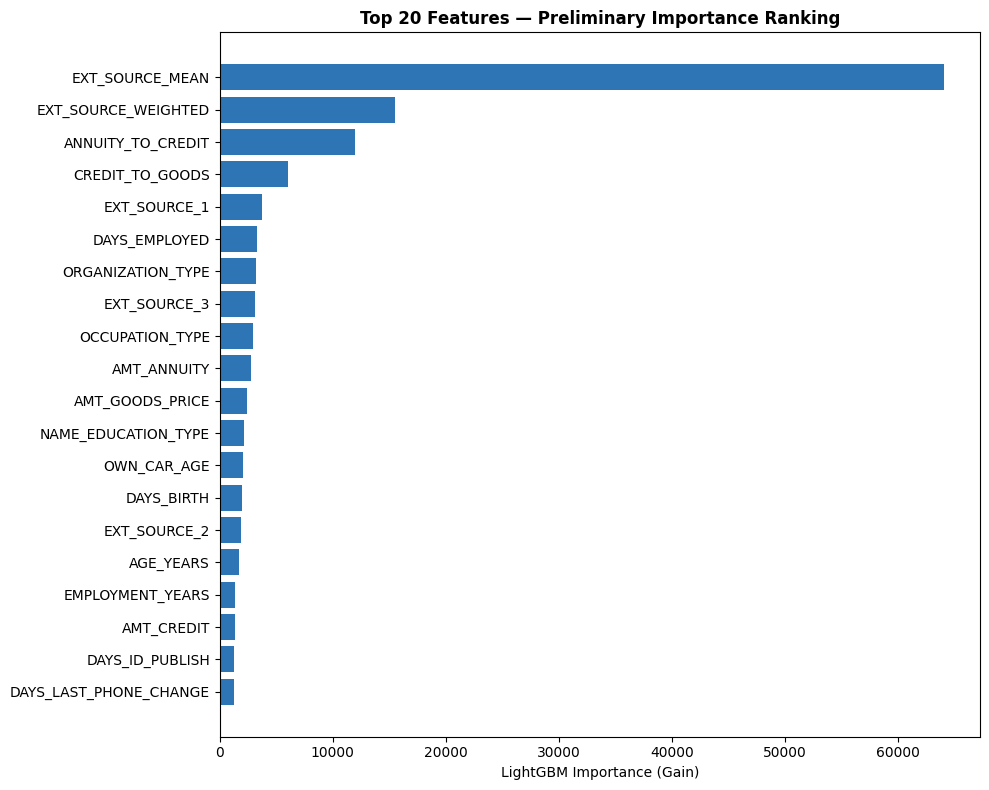


Chart saved: docs/feature_importance_preliminary.png


In [60]:
# ── SAVE FINAL FEATURE LIST AND PROCESSED DATA ────────────────────────────────
import os

# Save feature list
with open('../docs/feature_list.txt', 'w') as f:
    f.write(f"Final Feature List — {len(truly_final_features)} features\n")
    f.write(f"Generated: Step 3.5 Feature Selection\n\n")
    for feat in truly_final_features:
        f.write(f"{feat}\n")

print(f"Feature list saved: docs/feature_list.txt")

# Create processed data folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the full processed dataframe (keep TARGET, SK_ID_CURR, CODE_GENDER_ENCODED 
# for reference even though they won't be used as training features)
cols_to_save = truly_final_features + ['TARGET', 'SK_ID_CURR', 'CODE_GENDER_ENCODED']
df[cols_to_save].to_csv('../data/processed/application_train_processed.csv', 
                         index=False)

print(f"Processed data saved: data/processed/application_train_processed.csv")
print(f"Shape saved: {df[cols_to_save].shape}")

# Save the top 20 feature importance chart for the README/portfolio
plt.figure(figsize=(10, 8))
top_20 = importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='#2E75B6')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('LightGBM Importance (Gain)')
plt.title('Top 20 Features — Preliminary Importance Ranking', 
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/feature_importance_preliminary.png', dpi=150)
plt.show()

print(f"\nChart saved: docs/feature_importance_preliminary.png")